In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)


def plot_wind(ax, emul_files, orig_files, title=""):
    n_models = len(emul_files)
    colors = plt.get_cmap("tab20", n_models)

    for i, (emul_file, orig_file) in enumerate(zip(emul_files, orig_files)):
        color = colors(i)

        # --- Emulated ---
        season_counts_np = np.load(emul_file, allow_pickle=True)
        if isinstance(season_counts_np, dict):
            season_counts_np = list(season_counts_np.values())[0]
        ensembles, n_seasons = season_counts_np.shape

        for e in range(ensembles):
            x = np.arange(n_seasons) + np.random.uniform(-0.2, 0.2, size=n_seasons)
            y = season_counts_np[e, :]
            ax.scatter(
                x,
                y,
                color=color,
                alpha=0.5,
                s=40,
                label=f"{os.path.basename(emul_file)} (emul)" if e == 0 else "",
            )

        # --- Original ---
        season_counts_np = np.load(orig_file, allow_pickle=True)
        if isinstance(season_counts_np, dict):
            season_counts_np = list(season_counts_np.values())[0]

        x = np.arange(n_seasons) + np.random.uniform(-0.2, 0.2, size=n_seasons)
        y = season_counts_np
        ax.scatter(
            x,
            y,
            color=color,
            edgecolor="black",
            s=120,
            alpha=0.9,
            label=f"{os.path.basename(orig_file)} (orig)",
        )

    season_names = ["Autumn", "Spring", "Summer", "Winter"]
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels(season_names)
    ax.set_title(title)

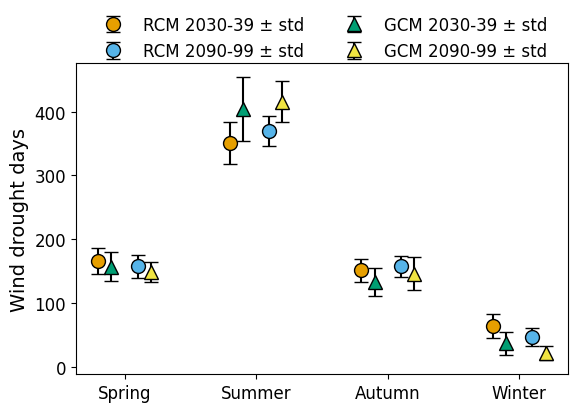

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# --- Collect files ---
orig_files1 = sorted(glob.glob("../plotting_data/orig_RCM_wind_id011/hist/*.npy"))
orig_files2 = sorted(glob.glob("../plotting_data/orig_RCM_wind_id011/*.npy"))
gcm_files1 = sorted(glob.glob("../plotting_data/GCM/30-39/wind/*.npy"))
gcm_files2 = sorted(glob.glob("../plotting_data/GCM/90-99/wind/*.npy"))


def load_arr(path):
    a = np.load(path, allow_pickle=True)
    return list(a.values())[0] if isinstance(a, dict) else a


plt.figure(figsize=(6, 4.5))
offset = 0.1
season_names = ["Spring", "Summer", "Autumn", "Winter"]
new_order = [1, 2, 0, 3]

# Colors
rcm_color1 = "#E69F00"
rcm_color2 = "#56B4E9"
gcm_color1 = "#009E73"
gcm_color2 = "#F0E442"


# --- Load data and stack ---
def stack_files(file_list):
    all_data = []
    for f in file_list:
        arr = load_arr(f)[new_order]
        all_data.append(arr)
    return np.vstack(all_data)


orig1_stack = stack_files(orig_files1)
orig2_stack = stack_files(orig_files2)
gcm1_stack = stack_files(gcm_files1)
gcm2_stack = stack_files(gcm_files2)

# --- Compute mean and std ---
orig1_mean, orig1_std = orig1_stack.mean(0), orig1_stack.std(0)
orig2_mean, orig2_std = orig2_stack.mean(0), orig2_stack.std(0)
gcm1_mean, gcm1_std = gcm1_stack.mean(0), gcm1_stack.std(0)
gcm2_mean, gcm2_std = gcm2_stack.mean(0), gcm2_stack.std(0)

x_vals = np.arange(len(orig1_mean))

# --- Plot errorbars only ---
plt.errorbar(
    x_vals - 2 * offset,
    orig1_mean,
    yerr=orig1_std,
    fmt="o",
    color=rcm_color1,
    markeredgecolor="black",
    ecolor="black",
    markersize=10,
    capsize=5,
    label="RCM 2030-39 ± std",
)

plt.errorbar(
    x_vals + 1 * offset,
    orig2_mean,
    yerr=orig2_std,
    fmt="o",
    color=rcm_color2,
    markeredgecolor="black",
    ecolor="black",
    markersize=10,
    capsize=5,
    label="RCM 2090-99 ± std",
)

plt.errorbar(
    x_vals - 1 * offset,
    gcm1_mean,
    yerr=gcm1_std,
    fmt="^",
    color=gcm_color1,
    markeredgecolor="black",
    ecolor="black",
    markersize=10,
    capsize=5,
    label="GCM 2030-39 ± std",
)

plt.errorbar(
    x_vals + 2 * offset,
    gcm2_mean,
    yerr=gcm2_std,
    fmt="^",
    color=gcm_color2,
    markeredgecolor="black",
    ecolor="black",
    markersize=10,
    capsize=5,
    label="GCM 2090-99 ± std",
)

# --- Axis and legend ---
plt.xticks(np.arange(4), season_names)
plt.ylabel("Wind drought days")

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=2, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.savefig("../plots/0086_plot_future_past_wind_with_gcm_errorbars_only.pdf")
plt.show()

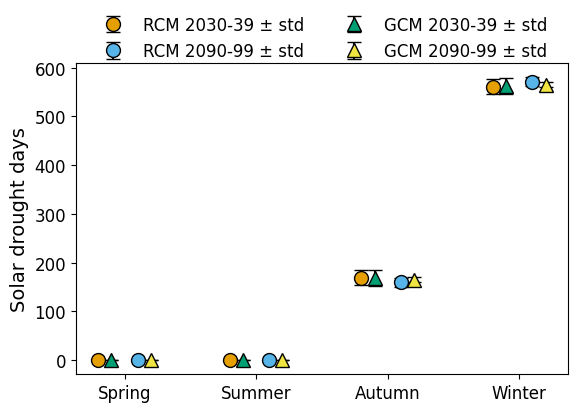

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# --- Collect files ---
orig_files1 = sorted(glob.glob("../plotting_data/orig_RCM_solar_id011/hist/*.npy"))
orig_files2 = sorted(glob.glob("../plotting_data/orig_RCM_solar_id011/*.npy"))
gcm_files1 = sorted(glob.glob("../plotting_data/GCM/30-39/solar/*.npy"))
gcm_files2 = sorted(glob.glob("../plotting_data/GCM/90-99/solar/*.npy"))


def load_arr(path):
    a = np.load(path, allow_pickle=True)
    return list(a.values())[0] if isinstance(a, dict) else a


plt.figure(figsize=(6, 4.5))
offset = 0.1
season_names = ["Spring", "Summer", "Autumn", "Winter"]
new_order = [1, 2, 0, 3]


# --- Load data and stack ---
def stack_files(file_list):
    all_data = []
    for f in file_list:
        arr = load_arr(f)[new_order]
        all_data.append(arr)
    return np.vstack(all_data)


orig1_stack = stack_files(orig_files1)
orig2_stack = stack_files(orig_files2)
gcm1_stack = stack_files(gcm_files1)
gcm2_stack = stack_files(gcm_files2)

# --- Compute mean and std ---
orig1_mean, orig1_std = orig1_stack.mean(0), orig1_stack.std(0)
orig2_mean, orig2_std = orig2_stack.mean(0), orig2_stack.std(0)
gcm1_mean, gcm1_std = gcm1_stack.mean(0), gcm1_stack.std(0)
gcm2_mean, gcm2_std = gcm2_stack.mean(0), gcm2_stack.std(0)

x_vals = np.arange(len(orig1_mean))

# --- Plot errorbars only ---
plt.errorbar(
    x_vals - 2 * offset,
    orig1_mean,
    yerr=orig1_std,
    fmt="o",
    color=rcm_color1,
    markeredgecolor="black",
    ecolor="black",
    markersize=10,
    capsize=5,
    label="RCM 2030-39 ± std",
)

plt.errorbar(
    x_vals + 1 * offset,
    orig2_mean,
    yerr=orig2_std,
    fmt="o",
    color=rcm_color2,
    markeredgecolor="black",
    ecolor="black",
    markersize=10,
    capsize=5,
    label="RCM 2090-99 ± std",
)

plt.errorbar(
    x_vals - 1 * offset,
    gcm1_mean,
    yerr=gcm1_std,
    fmt="^",
    color=gcm_color1,
    markeredgecolor="black",
    ecolor="black",
    markersize=10,
    capsize=5,
    label="GCM 2030-39 ± std",
)

plt.errorbar(
    x_vals + 2 * offset,
    gcm2_mean,
    yerr=gcm2_std,
    fmt="^",
    color=gcm_color2,
    markeredgecolor="black",
    ecolor="black",
    markersize=10,
    capsize=5,
    label="GCM 2090-99 ± std",
)

# --- Axis and legend ---
plt.xticks(np.arange(4), season_names)
plt.ylabel("Solar drought days")

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=2, frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.savefig("../plots/0086_plot_future_past_solar_with_gcm_errorbars_only.pdf")
plt.show()